# Machine learning enriched

In [1]:
import pandas as pd
import numpy as np
from pycaret.classification import *

## Loading data

In [2]:
# Load encoded feature matrices saved during feature engineering
X_train = pd.read_csv('../data/features/X_train_enriched.csv')
X_test = pd.read_csv('../data/features/X_test_enriched.csv')

# Load target vectors — squeeze converts single-column DataFrame to Series
y_train = pd.read_csv('../data/features/y_train_enriched.csv').squeeze()
y_test = pd.read_csv('../data/features/y_test_enriched.csv').squeeze()

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).round(3)}')

X_train shape: (234436, 54)
X_test shape:  (58609, 54)
y_train distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64
y_test distribution:
citation_top_10_percent
0    0.82
1    0.18
Name: proportion, dtype: float64


## Combining train data for PyCaret

In [3]:
# PyCaret setup() requires a single DataFrame with features + target combined
# X_test and y_test are kept separate for final evaluation after modelling
train_data = X_train.copy()
train_data['target'] = y_train.values

print(f'Train data shape: {train_data.shape}')
print(f'Target distribution:\n{train_data["target"].value_counts()}')

Train data shape: (234436, 55)
Target distribution:
target
0    192194
1     42242
Name: count, dtype: int64


##  PyCaret setup

In [4]:
# Initialise PyCaret experiment
# - target: column to predict
# - test_data: holdout set — PyCaret will never touch this during training
# - fix_imbalance: applies SMOTE to training folds only to handle 82/18 class imbalance
# - session_id: random seed for reproducibility
# - index=False: resets index to RangeIndex to avoid duplicate index error
# - verbose: shows setup summary table
experiment = setup(
    data=train_data,
    target='target',
    test_data=pd.concat([X_test, y_test.rename('target')], axis=1).reset_index(drop=True),
    fix_imbalance=True,
    session_id=42,
    index=False,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,target
2,Target type,Binary
3,Original data shape,"(293045, 55)"
4,Transformed data shape,"(442997, 55)"
5,Transformed train set shape,"(384388, 55)"
6,Transformed test set shape,"(58609, 55)"
7,Numeric features,54
8,Preprocess,True
9,Imputation type,simple


## Compare models

In [5]:
# Compare all available classification models
# metric: optimise ranking by F1 score — appropriate for imbalanced classification
# sort: rank models by F1
# n_select: keep top 5 models for further analysis
best_models = compare_models(
    sort='F1',
    n_select=5,
    verbose=True
)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8311,0.8412,0.5195,0.5323,0.5257,0.4230,0.4231,31.6610
ada,Ada Boost Classifier,0.7979,0.8169,0.5854,0.4529,0.5106,0.3859,0.3910,9.9630
ridge,Ridge Classifier,0.7390,0.8194,0.7544,0.3854,0.5102,0.3568,0.3942,2.6530
lda,Linear Discriminant Analysis,0.7390,0.8194,0.7544,0.3854,0.5102,0.3568,0.3941,4.3950
lr,Logistic Regression,0.7377,0.8092,0.7330,0.3815,0.5018,0.3470,0.3811,21.5510
xgboost,Extreme Gradient Boosting,0.8490,0.8543,0.3881,0.6318,0.4807,0.3982,0.4145,5.4950
lightgbm,Light Gradient Boosting Machine,0.8476,0.8527,0.3907,0.6231,0.4802,0.3964,0.4113,6.1060
catboost,CatBoost Classifier,0.8500,0.8572,0.3826,0.6406,0.4790,0.3978,0.4159,45.1750
rf,Random Forest Classifier,0.8436,0.8417,0.3780,0.6061,0.4656,0.3797,0.3943,25.2630
knn,K Neighbors Classifier,0.6983,0.7584,0.7198,0.3405,0.4623,0.2882,0.3272,22.0210


In [12]:
from pycaret.classification import save_model

save_model(best_models[0], '../models/gbc_enriched')
print("Saved: models/gbc_enriched.pkl")

Transformation Pipeline and Model Successfully Saved
Saved: models/gbc_enriched.pkl


## Model Comparison Results

15 classification models were compared using 10-fold stratified cross-validation 
with SMOTE applied to training folds to handle the 82/18 class imbalance.
Models are ranked by F1 score — the primary metric for imbalanced classification.

**Winner: Gradient Boosting Classifier (gbc)**
- F1 = 0.54 — best balance of precision and recall
- AUC = 0.84 — strong class separation ability
- Beats the dummy baseline (F1 = 0.00) significantly

**Key observations:**
- XGBoost and CatBoost achieve the highest AUC (0.85) but lower F1 (0.49, 0.48)
  — they are better at overall class separation but less balanced on precision/recall
- Accuracy is a misleading metric here — the dummy classifier scores 0.82 accuracy
  by always predicting the majority class, confirming F1 is the right primary metric
- No model exceeded F1 = 0.55 — expected given only metadata features are available
  at publication time, with no full text, author network or venue quality signals
- GBC is selected for hyperparameter tuning and SHAP analysis

## SHAP analysis - GBC model

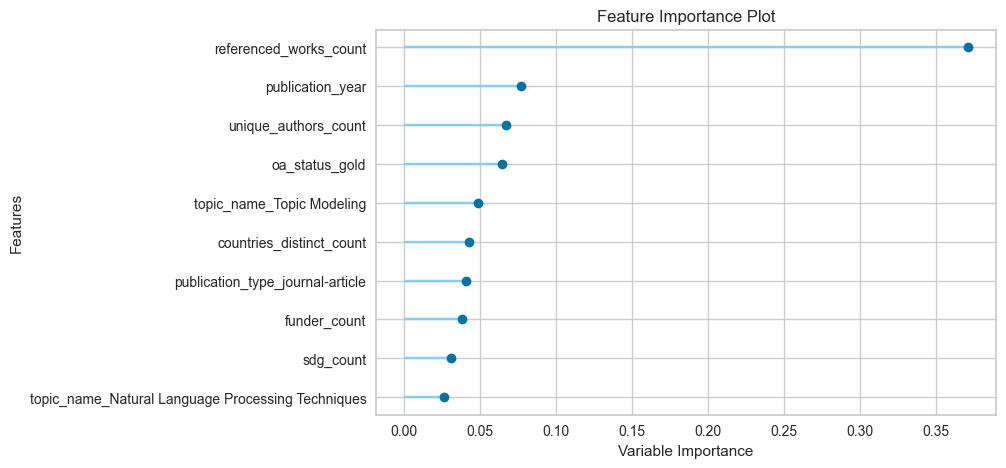

In [6]:
# Plot feature importance for the best model
plot_model(best_models[0], plot='feature')

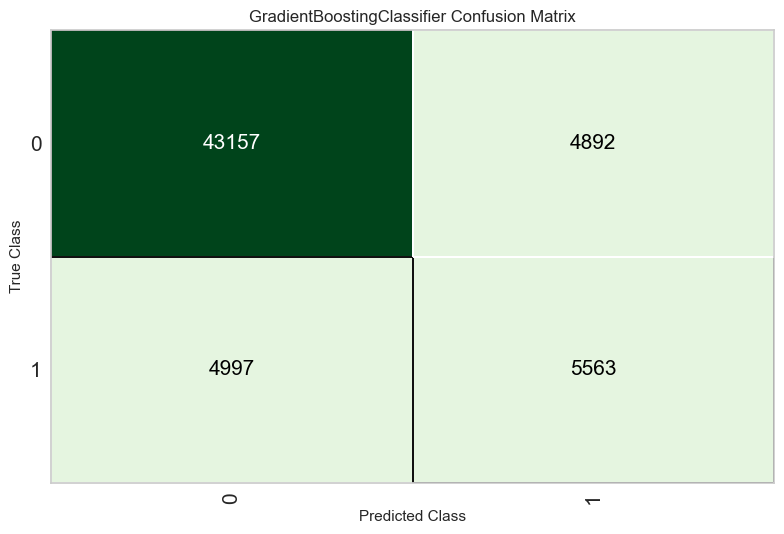

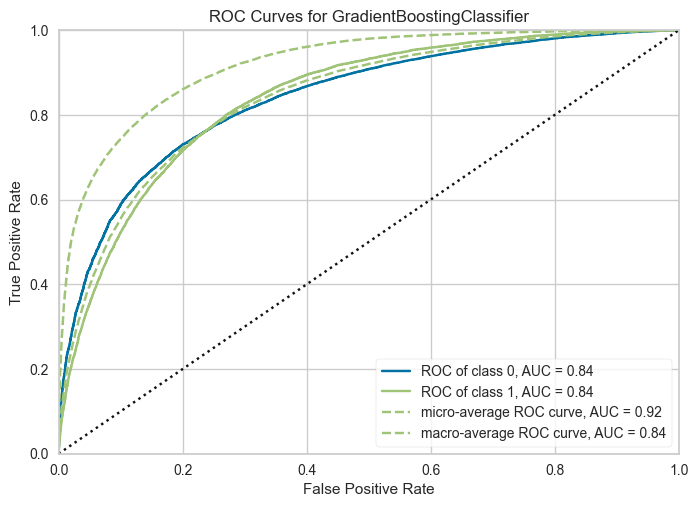

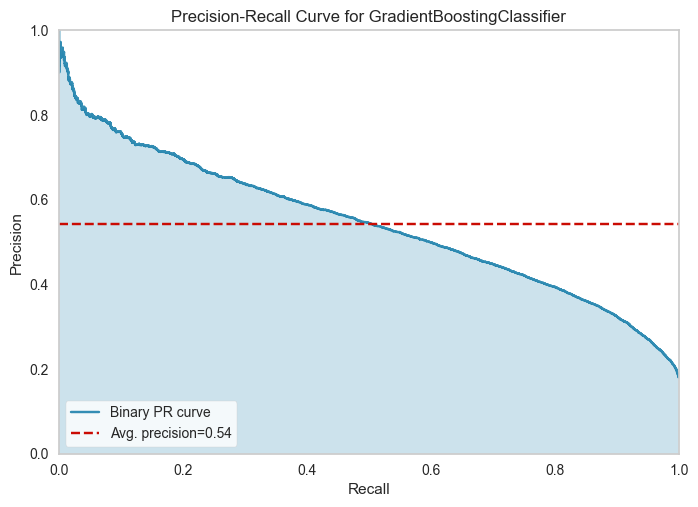

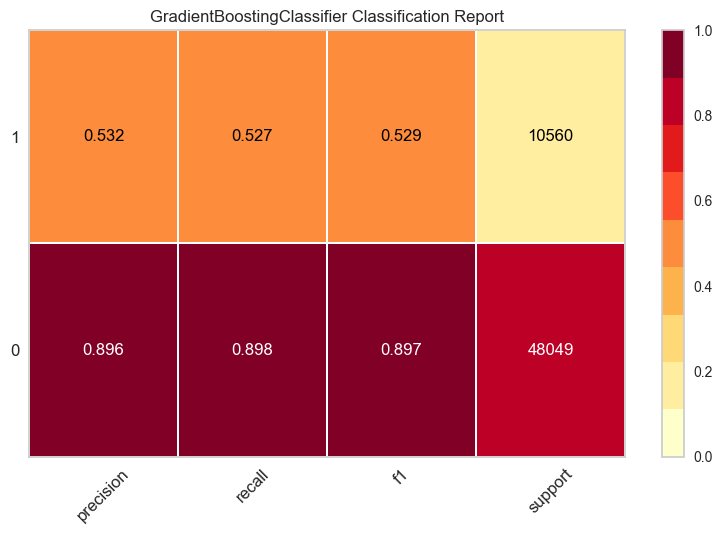

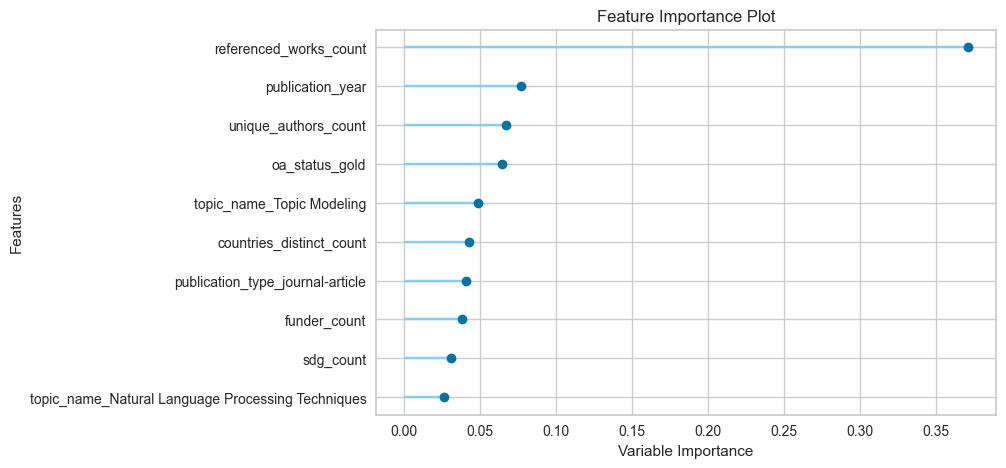

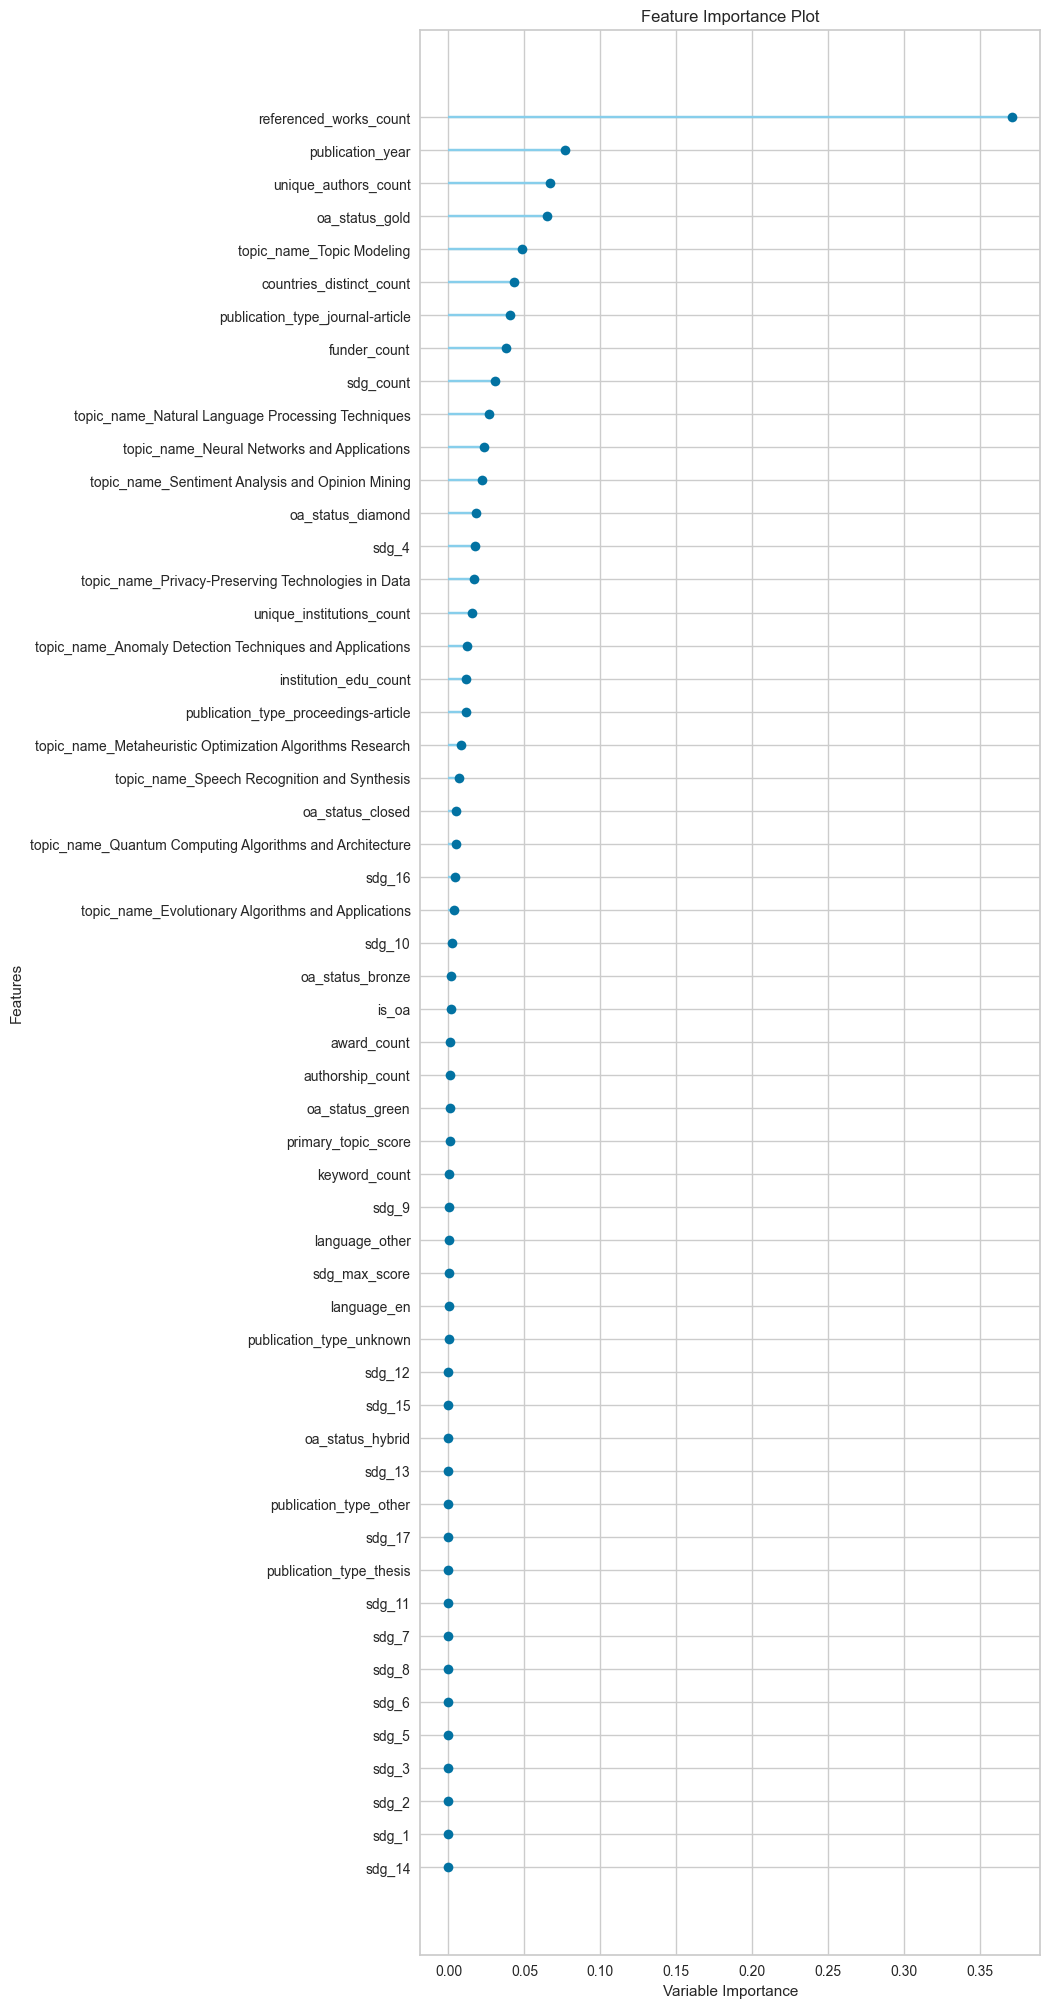

In [8]:
# Confusion matrix — shows true/false positives and negatives
plot_model(best_models[0], plot='confusion_matrix')

# AUC-ROC curve
plot_model(best_models[0], plot='auc')

# Precision-Recall curve — more informative than AUC for imbalanced data
plot_model(best_models[0], plot='pr')

# Classification report — precision, recall, F1 per class
plot_model(best_models[0], plot='class_report')

# Feature importance
plot_model(best_models[0], plot='feature')

# Feature importance
plot_model(best_models[0], plot='feature_all')

## Model Evaluation — Enriched GBC (Pre-Tuning Baseline)

### Results vs First Model

| Metric | First Model (GBC, 30 features) | Enriched Model (GBC, 54 features) |
|---|---|---|
| F1 | 0.54 | 0.53 |
| AUC-ROC | 0.84 | 0.84 |
| Recall | 0.61 | 0.53 |
| Precision | 0.49 | 0.53 |
| True Positives | 6,421 | 5,563 |
| False Negatives | 4,139 | 4,997 |
| False Positives | 6,776 | 4,892 |
| True Negatives | 41,273 | 43,157 |

### Interpretation

AUC-ROC is unchanged at 0.84 — the enriched model has the same underlying 
discriminative power as the first model. The additional features have not 
degraded the model's ability to separate high-impact from non-high-impact papers.

However, the enriched model has shifted toward precision at the expense of recall.
It flags fewer papers overall (10,455 vs 13,197) and is more accurate when it does,
but misses 858 more high-impact papers than the first model. For the publisher and
funder use cases, this is the wrong tradeoff — recall is the priority.

The PR curve confirms headroom exists: precision stays above 0.40 up to recall ~0.75,
suggesting the operating point can be shifted without significant precision collapse.

### Feature Importance — Key Findings

- `referenced_works_count` remains dominant (importance ~0.38) — unchanged from 
  first model
- `unique_authors_count` (~0.06) outperforms `authorship_count` (~0.00) — the 
  enriched pull provides a more useful author signal
- `funder_count` (~0.03) and `sdg_count` (~0.03) are meaningful new signals
- `unique_institutions_count`, `institution_edu_count`, `award_count` near-zero —
  redundant given correlated features with higher importance
- All individual `sdg_1`–`sdg_17` flags near-zero except `sdg_4` — sparse binary
  flags adding noise rather than signal

### Decision

The recall drop is a threshold and feature noise issue, not a loss of signal.

Next steps:
1. Rebuild trimmed feature set — drop zero-importance and redundant correlated 
   features (~54 → ~35 features)
2. Retrain and rerun compare_models() on trimmed set
3. Tune best model with `optimize='Recall'` rather than `optimize='F1'`
4. Apply threshold adjustment post-tuning to target recall ~0.65–0.70

## SHAP analysis - XGB model

In [13]:
# Create and save XGBoost model
xgb = create_model('xgboost', session_id=42)
save_model(xgb, '../models/xgb_enriched')
print("Saved: models/xgb_enriched.pkl")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8516,0.8567,0.4093,0.6375,0.4986,0.4163,0.4304
1,0.8471,0.8548,0.3778,0.6251,0.4710,0.3879,0.4047
2,0.8513,0.8590,0.3875,0.6453,0.4842,0.4036,0.4215
3,0.8494,0.8523,0.3920,0.6325,0.4841,0.4016,0.4173
4,0.8472,0.8527,0.3763,0.6267,0.4703,0.3874,0.4047
5,0.8478,0.8504,0.3851,0.6263,0.4769,0.3937,0.4097
6,0.8488,0.8597,0.3906,0.6298,0.4822,0.3993,0.4149
7,0.8507,0.8568,0.3946,0.6385,0.4878,0.4060,0.4221
8,0.8487,0.8512,0.3752,0.6358,0.4719,0.3904,0.4089


Transformation Pipeline and Model Successfully Saved
Saved: models/xgb_enriched.pkl


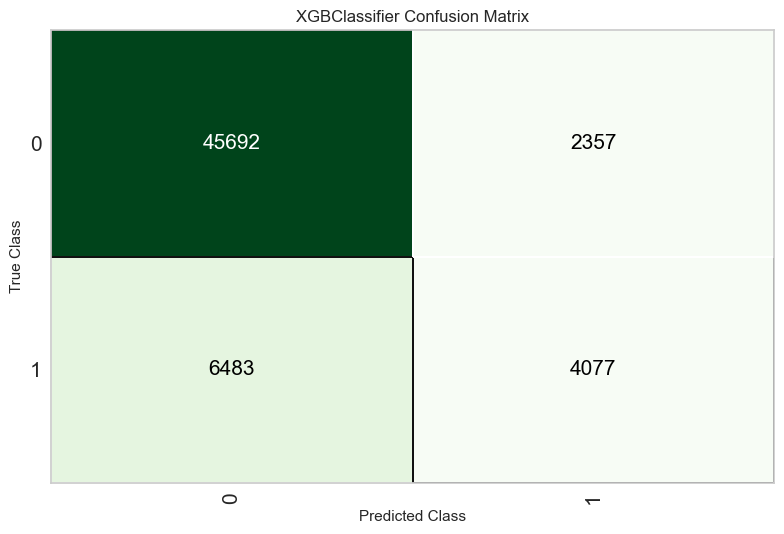

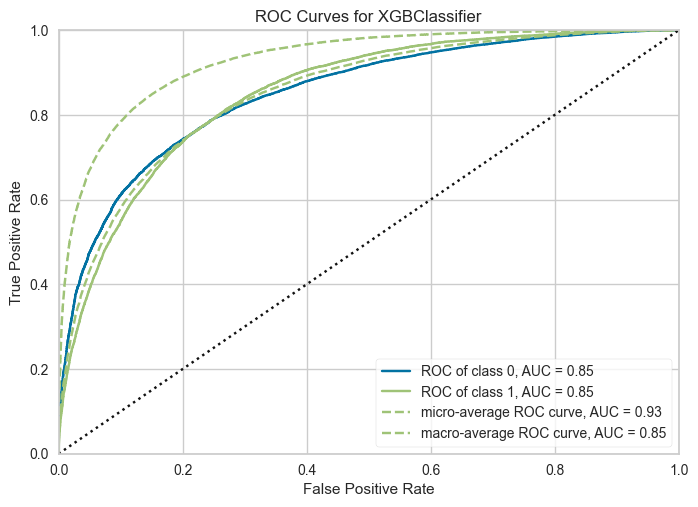

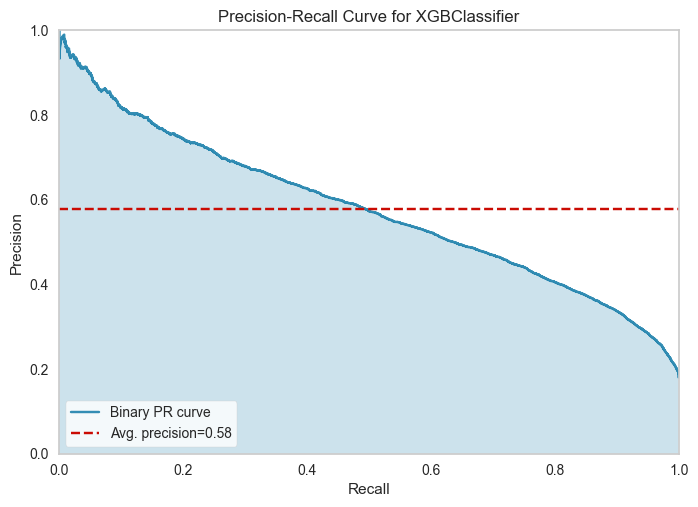

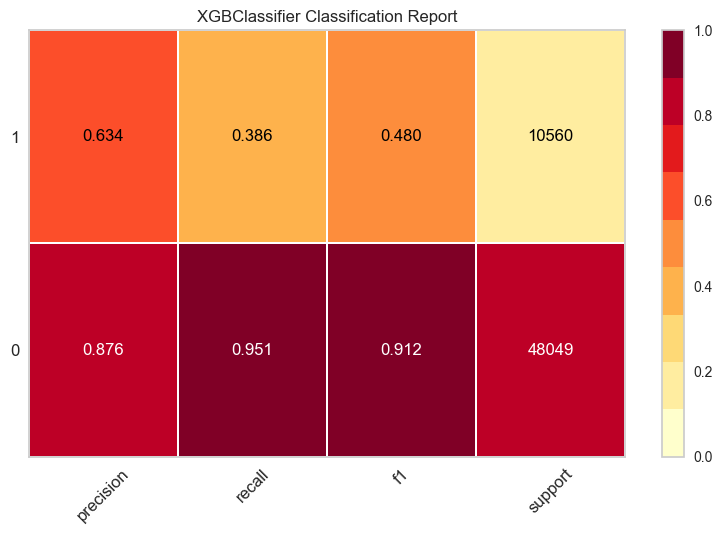

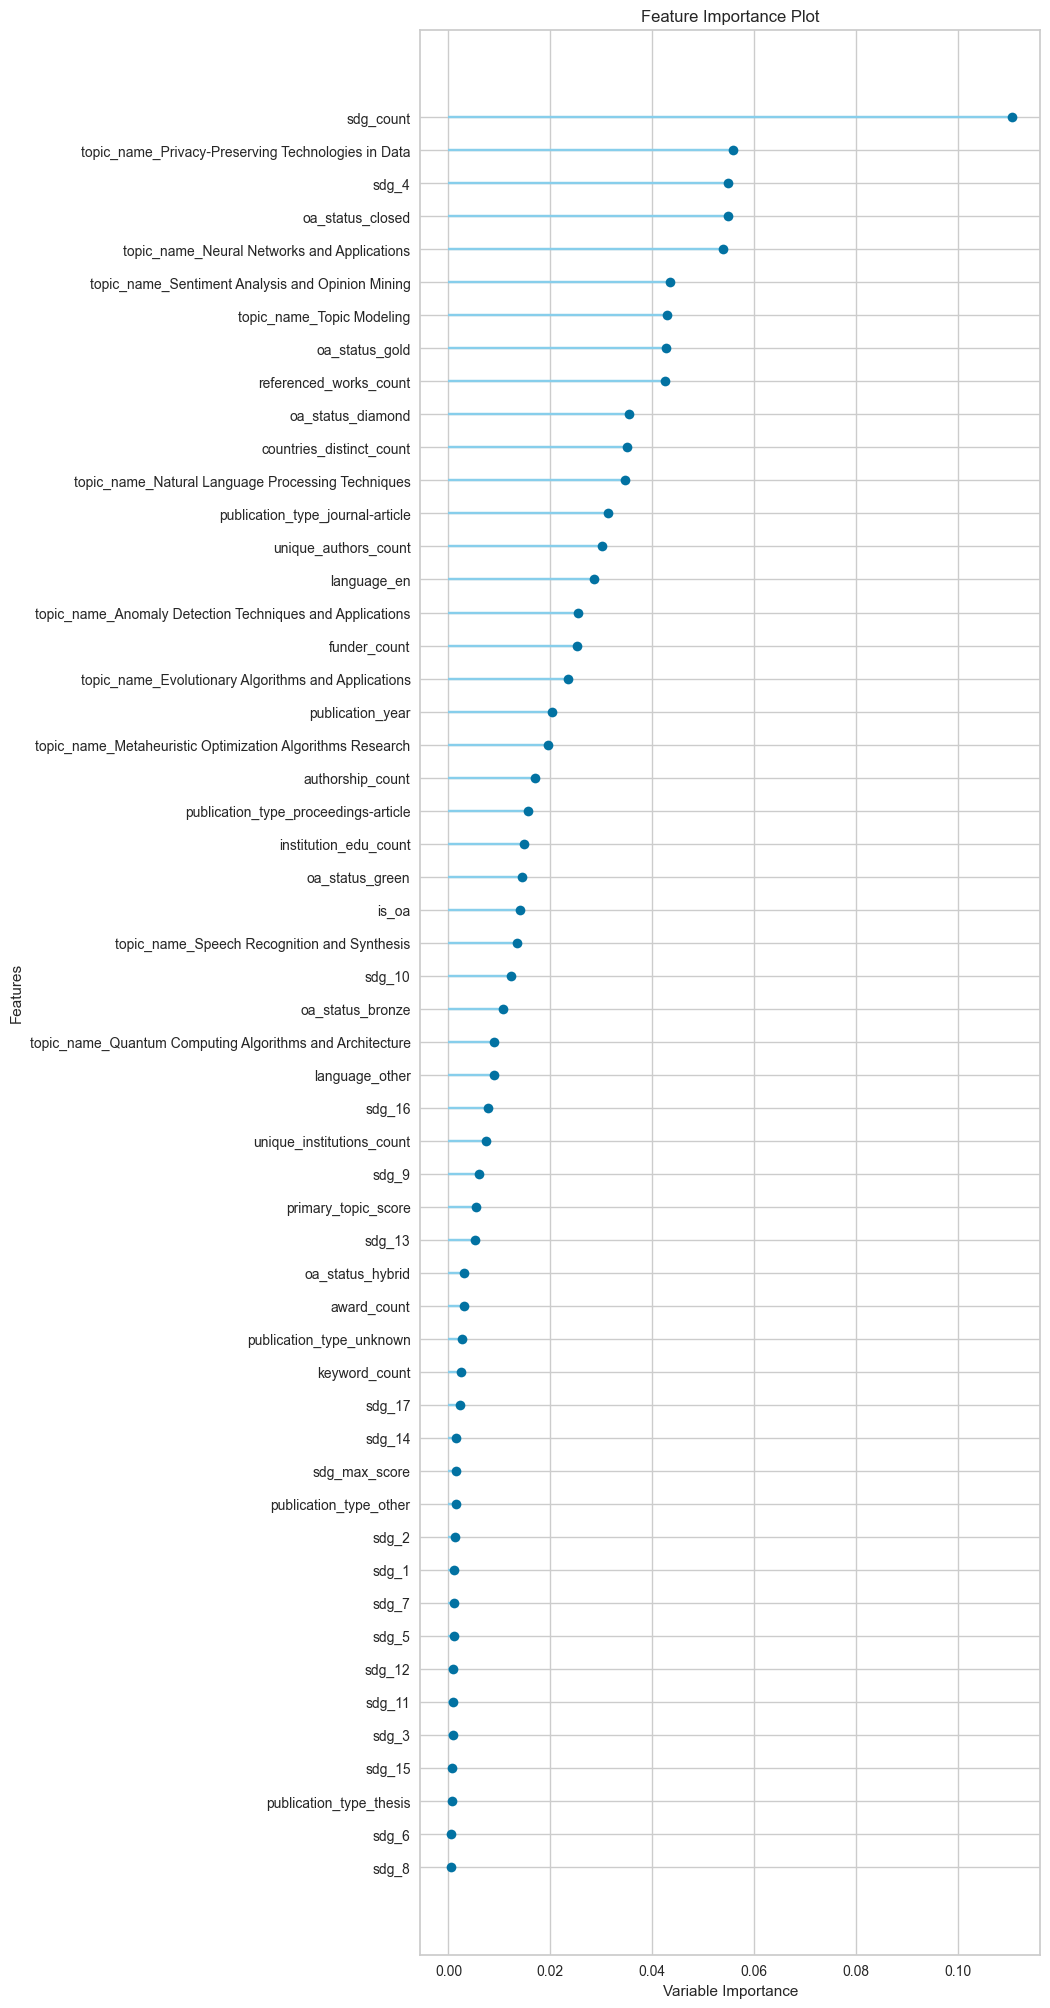

In [14]:
plot_model(xgb, plot='confusion_matrix')
plot_model(xgb, plot='auc')
plot_model(xgb, plot='pr')
plot_model(xgb, plot='class_report')
plot_model(xgb, plot='feature_all')

## Model Evaluation — Enriched XGBoost

### Results vs GBC

| Metric | GBC (enriched) | XGBoost (enriched) |
|---|---|---|
| F1 | 0.53 | 0.48 |
| AUC-ROC | 0.84 | 0.85 |
| Recall | 0.53 | 0.39 |
| Precision | 0.53 | 0.63 |
| True Positives | 5,563 | 4,077 |
| False Negatives | 4,997 | 6,483 |
| False Positives | 4,892 | 2,357 |
| True Negatives | 43,157 | 45,692 |

### Interpretation

XGBoost has marginally better discriminative power (AUC 0.85, PR AUC 0.58 vs 0.54)
but defaults to a heavily precision-skewed threshold — missing 6,483 high-impact 
papers vs 4,997 for GBC. Wrong tradeoff for the publisher use case.

Feature importance is distorted: `sdg_count` is dominant despite ρ=0.04 with the 
target, and `referenced_works_count` has dropped to 9th place. This suggests 
XGBoost is overfitting to sparse SDG features.

### Decision

GBC preferred over XGBoost at this stage. XGBoost will be revisited after 
the trimmed feature set removes SDG noise — its higher PR AUC suggests latent 
potential if the feature distortion is resolved.